In [1]:
import sys
import os

# Adds the parent directory (root) to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import holidays

In [3]:
df = pd.read_csv('../data/raw/cleaned_transactions.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale


In [4]:
df.shape

(514547, 9)

In [5]:
df.isna().sum()

InvoiceNo                0
StockCode                0
Description              0
Quantity                 0
InvoiceDate              0
Price                    0
Customer ID         103815
Country                  0
transaction_type         0
dtype: int64

In [6]:
df = df[df["Quantity"] > 0]
df.shape[0]

504731

In [7]:
df["Quantity"].describe()

count    504731.000000
mean         11.516923
std          87.337497
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64

In [8]:
df = df.sort_values(by = "Quantity", ascending = False)
df["Quantity"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]) 

0.50      3.0
0.75     12.0
0.90     24.0
0.95     32.0
0.99    120.0
Name: Quantity, dtype: float64

<Axes: xlabel='Quantity', ylabel='Count'>

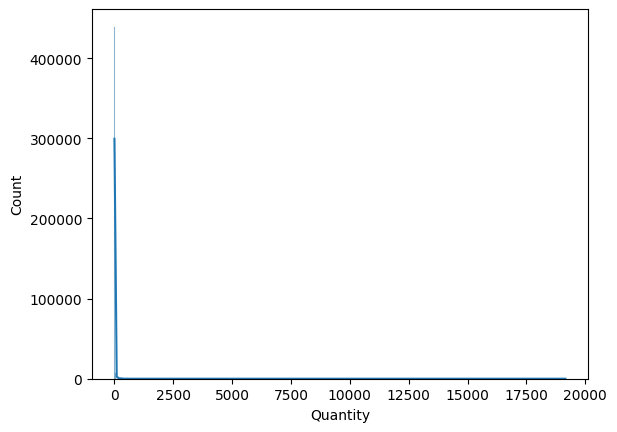

In [9]:
# plot histogram of quantity
sns.histplot(data=df, x="Quantity", kde=True)

In [10]:
df["Description"].value_counts().sort_values(ascending = False)

Description
WHITE HANGING HEART T-LIGHT HOLDER    3409
REGENCY CAKESTAND 3 TIER              2034
STRAWBERRY CERAMIC TRINKET BOX        1678
ASSORTED COLOUR BIRD ORNAMENT         1435
PACK OF 72 RETRO SPOT CAKE CASES      1435
                                      ... 
CUBIC MUG TEATIME CAKES                  1
ASSORTED DESIGN GEISHA GIRL MUGS         1
BLUE TILED SET OF 3 DRAWERS              1
SILVER PURSE GOLD PINK BUTTERFLY         1
3 BIRDS CANVAS SCREEN                    1
Name: count, Length: 4534, dtype: int64

In [11]:
df["StockCode"].value_counts()

StockCode
85123A      3375
22423       2034
85099B      2000
21212       1887
21232       1678
            ... 
S              1
DCGS0062       1
84731          1
84867a         1
47594a         1
Name: count, Length: 4251, dtype: int64

In [12]:
df[df["StockCode"] == "AMAZONFEE"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
507160,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,Sale
431589,531411,AMAZONFEE,AMAZON FEE,1,2010-11-08 10:11:00,6706.71,NaN,United Kingdom,Sale


In [13]:
df_sorted = df.sort_values(by=["Quantity"], ascending=False)
grp_sku = df_sorted.groupby("StockCode")
grp_sku.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
88942,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark,Sale
124450,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,Sale
124448,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,Sale
124451,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902.0,Denmark,Sale
124449,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902.0,Denmark,Sale
...,...,...,...,...,...,...,...,...,...
69798,495776,ADJUST,Adjustment by john on 26/01/2010 17,1,2010-01-26 17:03:00,49.35,17940.0,United Kingdom,Sale
69796,495773,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:57:00,4.57,12600.0,Germany,Sale
69790,495766,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:38:00,84.58,12709.0,Germany,Sale
69722,495736,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:23:00,21.00,12606.0,Spain,Sale


In [14]:
# Group by StockCode and calculate the min and max of Quantity
sku_ranges = df.groupby('StockCode')['Quantity'].agg(['min', 'max'])

# Calculate the span/spread of the range
sku_ranges['range_size'] = sku_ranges['max'] - sku_ranges['min']

# Sort by maximum volume to find high-volume items quickly
sku_ranges = sku_ranges.sort_values(by='max', ascending=False)

print(sku_ranges.head(20))

           min    max  range_size
StockCode                        
37410        1  19152       19151
21099        1  12960       12959
21091        1  12960       12959
21085        1  12744       12743
21092        1  12480       12479
21984        1  10000        9999
21982        1  10000        9999
21981        1  10000        9999
21980        1  10000        9999
85220       12   9456        9444
84347        1   9360        9359
20993        1   9312        9311
21088        1   7128        7127
17003        1   7128        7127
21096        1   7008        7007
20991        1   6768        6767
47503E       1   6696        6695
16044        1   6144        6143
37351        1   5364        5363
20759        1   5280        5279


In [15]:
sku_ranges[sku_ranges["min"] >= 12]

,min,max,range_size
StockCode,,,
85220,12,9456,9444
85218,24,1968,1944
22708,25,800,775
16156S,25,600,575
84760L,560,560,0
...,...,...,...
90127A,12,12,0
22933,12,12,0
44228,12,12,0


In [16]:
sku_ranges[sku_ranges["max"] <= 5 ]

,min,max,range_size
StockCode,,,
22802,1,5,4
84660C,1,5,4
85079,1,5,4
90147,1,5,4
84874B,1,5,4
...,...,...,...
35598A,1,1,0
90130C,1,1,0
85024A,1,1,0


In [17]:
sku_ranges[sku_ranges["max"] <= 12 ]

,min,max,range_size
StockCode,,,
90214R,1,12,11
90202D,1,12,11
90200E,1,12,11
85097B,1,12,11
84659A,1,12,11
...,...,...,...
35598A,1,1,0
90130C,1,1,0
85024A,1,1,0


Most SKU orders range from 1 to thousands of units, which almost certainly isn't one demand pattern but different demand patterns getting mixed together in the same rows. In practice this usually means a SKU is being bought by two different customer types: individual/retail buyers ordering a handful of units, and wholesale/reseller accounts occasionally placing bulk orders. So not useful for segmentation alone.

In [18]:
# Group by customer and calculate the min and max of Quantity
cust_ranges = df.groupby('Customer ID')['Quantity'].agg(['min', 'max'])

# Calculate the span/spread of the range
cust_ranges['range_size'] = cust_ranges['max'] - cust_ranges['min']

# Sort by maximum volume to find high-volume items quickly
cust_ranges = cust_ranges.sort_values(by='max', ascending=False)

print(cust_ranges.head(20))

              min    max  range_size
Customer ID                         
13902.0         4  19152       19148
17940.0         1  10000        9999
15838.0        50   9360        9310
14277.0         1   7128        7127
13687.0        72   7128        7056
16754.0        27   4320        4293
18008.0         1   3500        3499
16308.0      2000   3000        1000
18052.0       176   2972        2796
12931.0        20   2880        2860
13316.0         1   2880        2879
14609.0        36   2400        2364
15299.0        69   1824        1755
16467.0        30   1800        1770
13027.0       240   1680        1440
17949.0         1   1512        1511
13848.0      1000   1500         500
12755.0         1   1488        1487
13694.0         2   1440        1438
12482.0         1   1440        1439


In [19]:
cust_ranges[cust_ranges["min"] > 1000]

,min,max,range_size
Customer ID,,,
16308.0,2000,3000,1000
17369.0,1152,1152,0


In [20]:
cust_ranges[cust_ranges["min"] > 500]

,min,max,range_size
Customer ID,,,
16308.0,2000,3000,1000
13848.0,1000,1500,500
17369.0,1152,1152,0
13942.0,1000,1000,0
14028.0,730,830,100
17805.0,648,648,0
14956.0,625,625,0
12908.0,600,600,0
14845.0,600,600,0


In [21]:
# aggregate daily by sku and check range
# Convert 'InvoiceDate' to datetime and extract day from timestamp
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()

def aggregate_daily_demand(df):

    daily_demand = (
        df.groupby(
            ["InvoiceDate", "StockCode"],
            as_index=False
        )
        .agg(
            Quantity=("Quantity", "sum"),)
    )

    return daily_demand

daily_df = aggregate_daily_demand(df)

In [22]:
print(daily_df.sort_values(by='Quantity', ascending=False).head(20))

       InvoiceDate StockCode  Quantity
48277   2010-02-15     37410     19152
68900   2010-03-17     21091     12960
68904   2010-03-17     21099     12960
68897   2010-03-17     21085     12744
68901   2010-03-17     21092     12480
177287  2010-09-03     17003     11124
73093   2010-03-23     21984     11000
73092   2010-03-23     21982     10800
73091   2010-03-23     21981     10048
73090   2010-03-23     21980     10000
229031  2010-11-04     84347      9480
50122   2010-02-17     85220      9456
32631   2010-01-21     20993      9312
161587  2010-08-09     21088      7128
193383  2010-09-27     21088      7128
193385  2010-09-27     21096      7008
161589  2010-08-09     21096      7008
32630   2010-01-21     20991      6768
227873  2010-11-04     17003      6732
48292   2010-02-15    47503E      6696


In [23]:
print(daily_df.sort_values(by='Quantity', ascending=True).head(20))

       InvoiceDate StockCode  Quantity
210855  2010-10-15     90051         1
249972  2010-11-24     22406         1
71754   2010-03-21    79323S         1
249973  2010-11-24     22407         1
175672  2010-08-31    84884A         1
175673  2010-08-31     84901         1
71739   2010-03-21    72803A         1
71764   2010-03-21     82597         1
71738   2010-03-21    72802C         1
71734   2010-03-21     72793         1
249974  2010-11-24     22408         1
249975  2010-11-24     22409         1
71729   2010-03-21     72008         1
175675  2010-08-31    84912A         1
222702  2010-10-29     21427         1
71735   2010-03-21    72799D         1
249970  2010-11-24     22403         1
71770   2010-03-21     84219         1
71772   2010-03-21    84247H         1
71805   2010-03-21    84569C         1


In [24]:
one_unit = daily_df[daily_df["Quantity"] == 1]
one_unit["StockCode"].nunique()

3954

In [25]:
# 1. Filter for just the big orders (above 99th chosen threshold)
threshold = 120
big_orders = df[df['Quantity'] >= threshold].sort_values(['StockCode', 'InvoiceDate'])

# 2. Calculate the days between consecutive big orders for each item
big_orders['Days_Between'] = big_orders.groupby('StockCode')['InvoiceDate'].diff().dt.days

# 3. Find the average frequency of these massive spikes per item
spike_frequency = big_orders.groupby('StockCode')['Days_Between'].mean()

print(spike_frequency)

StockCode
10002      16.3125
10123C     49.0000
10123G     49.0000
10133          NaN
10134     215.0000
            ...   
85232B    255.0000
90057      27.0000
90167      79.5000
D              NaN
M         162.0000
Name: Days_Between, Length: 1339, dtype: float64


In [26]:
display(spike_frequency.sort_values(ascending = True))

StockCode
84748     0.0
22402     0.0
22399     0.0
22537     0.2
22965     1.0
         ... 
85226C    NaN
85227     NaN
85230A    NaN
85231L    NaN
D         NaN
Name: Days_Between, Length: 1339, dtype: float64

### Spike Frequency Insights

**NaN**: 

- The item only had exactly one huge order in the entire dataset. 
- **Business context**: This is a one-time fluke or a brand-new wholesale customer.  
- **Action:** Route to Manual/Buffer Layer. This is the definition of unpredictable data.

**Zero**:

-  The item had multiple huge orders, but they all happened on the exact same day (the time difference between them is 0 days). Multiple invoices, same SKU, same date.
- **The Business Context:** A single buyer placed multiple large orders at the same time (perhaps splitting their order across separate invoices), or multiple wholesale buyers rushed the store on the same day. 
- **Action:** Treated as a single event. Group these by day first so they become one single daily spike, rather than a frequency of zero.

**1.0**:

- Massive orders for this item happen exactly 1 day apart, consistently. 
- **The Business Context:** This item has an incredibly predictable, high-velocity wholesale demand. It is essentially a daily staple for bulk buyers. 
- **Action:** Keep in the ML Model Layer. This is a machine learning goldmine. Because the frequency is 1.0 (daily), standard time-series lags and rolling averages will easily learn and predict this pattern perfectly.

# Filter out low frequency / slow moving SKUs

In [27]:
def compute_sku_order_frequency(
    df,
    sku_col,
    date_col,
    invoice_col,
):
    """
    check frequency of sales for each sku and exclude those that have only very few orders 
    in the span of 1 year regardless of order size.
    """
    g = df.groupby(sku_col)

    freq = g.agg(
        n_orders=(invoice_col, "nunique"),
        n_active_days=(date_col, lambda x: x.dt.normalize().nunique()),
        first_sale=(date_col, "min"),
        last_sale=(date_col, "max"),
    ).reset_index()

    freq["active_span_days"] = (freq["last_sale"] - freq["first_sale"]).dt.days
    freq["active_span_months"] = (freq["active_span_days"] / 30.44).clip(lower=1)
    freq["orders_per_active_month"] = freq["n_orders"] / freq["active_span_months"]

    return freq

freq_df = compute_sku_order_frequency(df,  sku_col="StockCode",
    date_col="InvoiceDate",
    invoice_col="InvoiceNo",)

In [28]:
def flag_low_frequency_skus(
    freq_df,
    min_orders=5,
    min_active_days=3,
):
    """
    Simple, explainable threshold: exclude SKUs with fewer than
    `min_orders` distinct orders OR fewer than `min_active_days`
    distinct selling days across the whole training window.

    Two conditions rather than one because a SKU could show up on
    5 different invoices all placed the same day (bulk single-event
    purchase) -- that's still low information for learning a demand
    pattern over time, even though n_orders alone looks fine.
    """
    freq_df = freq_df.copy()
    freq_df["low_frequency"] = (
        (freq_df["n_orders"] < min_orders)
        | (freq_df["n_active_days"] < min_active_days)
    )
    return freq_df

freq_df = flag_low_frequency_skus(freq_df)
freq_df

,StockCode,n_orders,n_active_days,first_sale,last_sale,active_span_days,active_span_months,orders_per_active_month,low_frequency
0,10002,310,187,2009-12-01,2010-12-09,373,12.253614,25.298660,False
1,10002R,3,3,2009-12-02,2010-01-25,54,1.773982,1.691111,True
2,10080,5,5,2009-12-02,2010-11-21,354,11.629435,0.429944,False
3,10109,1,1,2009-12-03,2009-12-03,0,1.000000,1.000000,True
4,10120,47,42,2009-12-01,2010-12-08,372,12.220762,3.845914,False
...,...,...,...,...,...,...,...,...,...
4246,gift_0001_40,2,2,2010-08-10,2010-10-21,72,2.365309,0.845556,True
4247,gift_0001_50,2,2,2009-12-18,2010-10-07,293,9.625493,0.207782,True
4248,gift_0001_70,1,1,2010-06-14,2010-06-14,0,1.000000,1.000000,True
4249,gift_0001_80,1,1,2009-12-14,2009-12-14,0,1.000000,1.000000,True


In [29]:
freq_df["low_frequency"].value_counts()

low_frequency
False    3772
True      479
Name: count, dtype: int64

There are 479 slow moving SKUs that I need to exclude from modeling

In [30]:
from utils.sku_freq_check import summarize_frequency_distribution, report_exclusion_impact, classify_forecast_tier

In [31]:
summarize_frequency_distribution(freq_df)

Distribution of n_orders per SKU:
count    4251.000000
mean      117.236650
std       188.909192
min         1.000000
5%          2.000000
10%         4.000000
25%        13.000000
50%        48.000000
75%       139.500000
90%       318.000000
max      3281.000000
Name: n_orders, dtype: float64

Distribution of n_active_days per SKU:
count    4251.000000
mean       62.675841
std        66.705060
min         1.000000
5%          2.000000
10%         4.000000
25%        12.000000
50%        39.000000
75%        91.000000
90%       167.000000
max       306.000000
Name: n_active_days, dtype: float64


In [32]:
excluded_skus = report_exclusion_impact(df, freq_df, sku_col="StockCode", qty_col="Quantity")

SKUs excluded: 479 / 4251 (11.3%)
Rows excluded: 1114 / 504731 (0.2%)
Volume excluded: 21449 / 5812948 (0.4%)


In [33]:
new_df = df[~df["StockCode"].isin(excluded_skus)]
print(new_df.shape)

print(new_df["Quantity"].describe())

(503617, 9)
count    503617.000000
mean         11.499808
std          86.913313
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64


In [34]:
tiers = classify_forecast_tier(
    df,
    sku_col="StockCode",
    date_col="InvoiceDate",
    invoice_col="InvoiceNo",
    weekly_min_active_months_frac=0.8,   # active in ~80%+ of the observed span
    monthly_min_active_months=3,         # at least a handful of active months
)

print(tiers["forecast_tier"].value_counts())

forecast_tier
weekly     2358
monthly    1375
manual      518
Name: count, dtype: int64


In [35]:
merged_df = df.merge(tiers[["StockCode", "forecast_tier"]], on="StockCode")
print(merged_df.groupby("forecast_tier")["Quantity"].sum() / merged_df["Quantity"].sum())

forecast_tier
manual     0.007972
monthly    0.119996
weekly     0.872032
Name: Quantity, dtype: float64


In [36]:
merged_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type,forecast_tier
0,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15,0.1,13902.0,Denmark,Sale,monthly
1,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17,0.1,13902.0,Denmark,Sale,monthly
2,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17,0.1,13902.0,Denmark,Sale,weekly
3,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17,0.1,13902.0,Denmark,Sale,weekly
4,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17,0.1,13902.0,Denmark,Sale,monthly


In [37]:
manual = merged_df[merged_df["forecast_tier"] == "manual"]
manual["StockCode"].nunique()

518

In [38]:
weekly_skus = tiers.loc[tiers["forecast_tier"] == "weekly", "StockCode"]

new_df = df[df["StockCode"].isin(weekly_skus)]

new_df["Quantity"].describe()

#train_scoped = train_raw[train_raw["StockCode"].isin(weekly_skus)]
#test_scoped  = test_raw[test_raw["StockCode"].isin(weekly_skus)]

# From here, train_scoped/test_scoped feed into build_demand_features(),
# the p95 row filter, spike classification, etc. -- exactly as before,
# just on the correctly-scoped subset.

count    438031.000000
mean         11.572418
std          77.138227
min           1.000000
25%           1.000000
50%           4.000000
75%          12.000000
max       12960.000000
Name: Quantity, dtype: float64

In [39]:
new_df["Quantity"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]) 

0.50      4.0
0.75     12.0
0.90     24.0
0.95     32.0
0.99    120.0
Name: Quantity, dtype: float64

In [40]:
# monthly
monthly_skus = tiers.loc[tiers["forecast_tier"] == "monthly", "StockCode"]

m_df = df[df["StockCode"].isin(monthly_skus)]

m_df["Quantity"].describe()

count    63146.00000
mean        11.04629
std        137.66418
min          1.00000
25%          1.00000
50%          3.00000
75%         10.00000
max      19152.00000
Name: Quantity, dtype: float64

In [41]:
# Sanity check: exactly one row, one tier, per SKU
dupe_check = tiers.groupby("StockCode")["forecast_tier"].nunique()
assert (dupe_check == 1).all(), "Some SKUs have more than one tier assignment"

# Confirm every SKU appears in exactly one tier and counts sum correctly
print(tiers["forecast_tier"].value_counts())
print(f"Total SKUs across tiers: {tiers['forecast_tier'].value_counts().sum()}")
print(f"Total distinct SKUs: {tiers['StockCode'].nunique()}")  # should match

forecast_tier
weekly     2358
monthly    1375
manual      518
Name: count, dtype: int64
Total SKUs across tiers: 4251
Total distinct SKUs: 4251
